# 🔬 EDA, Cleaning & Feature Engineering — UCI Credit Card Default

Ce notebook est le **document de référence** pour la préparation des données.
Tout y est inline et documenté : chaque règle de nettoyage et chaque feature
dérivée a sa justification métier, sa formule, son code et sa validation
statistique.

**Dataset** : 30 000 clients de cartes de crédit taïwanais (Avril → Septembre
2005), 25 colonnes. Cible binaire : `default.payment.next.month`.

**Plan du notebook**

1. Setup
2. Vue structurelle des données brutes
3. Qualité des données — détection des anomalies
4. ✂️ **Cleaning détaillé** — 4 opérations avec before/after
5. Statistiques descriptives (post-cleaning)
6. Analyse de la cible
7. Analyse univariée
8. Analyse bivariée (variable vs cible) avec tests stats
9. Analyse multivariée (corrélations)
10. Détection des outliers
11. Analyses temporelles (6 mois)
12. 🛠️ **Feature engineering détaillé** — 12 features avec justification
13. Validation de l'utilité des nouvelles features
14. Sauvegarde du dataset processed

## 1. ⚙️ Setup

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = ROOT / 'data' / 'raw' / 'UCI_Credit_Card.csv'
PROCESSED_PATH = ROOT / 'data' / 'processed' / 'credit_clean.parquet'

print(f'ROOT      : {ROOT}')
print(f'RAW_PATH  : {RAW_PATH.relative_to(ROOT)}')
print(f'numpy     : {np.__version__}')
print(f'pandas    : {pd.__version__}')

ROOT      : /Users/oumarsy/Documents/master 2/mlops/Examen Mlops
RAW_PATH  : data/raw/UCI_Credit_Card.csv
numpy     : 1.26.4
pandas    : 2.2.3


## 2. Vue structurelle des données brutes

Objectif : comprendre la forme du dataset, les types, la cardinalité.

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Shape : {df_raw.shape}')
print(f'Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df_raw.head()

Shape : (30000, 25)
Memory: 5.72 MB


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df_raw.dtypes.value_counts()

float64    13
int64      12
Name: count, dtype: int64

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
# Cardinalité (nombre de valeurs uniques par colonne)
df_raw.nunique().sort_values()

default.payment.next.month        2
SEX                               2
MARRIAGE                          4
EDUCATION                         7
PAY_5                            10
PAY_6                            10
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
AGE                              56
LIMIT_BAL                        81
PAY_AMT5                       6897
PAY_AMT4                       6937
PAY_AMT6                       6939
PAY_AMT3                       7518
PAY_AMT2                       7899
PAY_AMT1                       7943
BILL_AMT6                     20604
BILL_AMT5                     21010
BILL_AMT4                     21548
BILL_AMT3                     22026
BILL_AMT2                     22346
BILL_AMT1                     22723
ID                            30000
dtype: int64

In [6]:
print('Doublons exactes :', df_raw.duplicated().sum())

Doublons exactes : 0


## 3. Qualité des données — détection des anomalies

Trois choses à vérifier :
- Valeurs manquantes
- **Codes catégoriels en dehors de la documentation officielle**
- Valeurs incohérentes (BILL_AMT négatif, etc.)

In [7]:
# Valeurs manquantes
missing = df_raw.isnull().sum()
print(f'Total NaN : {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])

Total NaN : 0


### 3.1 — Codes EDUCATION et MARRIAGE non documentés

D'après la documentation UCI :
- `EDUCATION` doit être dans `{1, 2, 3, 4}` (graduate school / university /
  high school / others)
- `MARRIAGE` doit être dans `{1, 2, 3}` (married / single / others)

Vérifions ce qu'on a vraiment dans les données brutes.

In [8]:
print('--- EDUCATION (valeurs brutes) ---')
print(df_raw['EDUCATION'].value_counts().sort_index())
print()
print('--- MARRIAGE (valeurs brutes) ---')
print(df_raw['MARRIAGE'].value_counts().sort_index())

--- EDUCATION (valeurs brutes) ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

--- MARRIAGE (valeurs brutes) ---
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


**Anomalies détectées :**
- `EDUCATION` contient les codes `0`, `5`, `6` qui ne sont pas dans la doc
  (345 clients soit 1.15% des données)
- `MARRIAGE` contient le code `0` (54 clients, 0.18%)

Ces codes sont vraisemblablement des erreurs de saisie ou des cas
inclassables. Nous les regrouperons dans la catégorie « others » lors
du cleaning (Section 4).

### 3.2 — Codes PAY_* (historique de paiement)

In [9]:
PAY_COLS = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
for col in PAY_COLS:
    print(f'{col} : {sorted(df_raw[col].unique())}')

PAY_0 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_2 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_3 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_4 : [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_5 : [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
PAY_6 : [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


**Lecture des codes PAY_* :**
- `-2` : pas d'utilisation ce mois-ci (no use)
- `-1` : payé en totalité, à l'heure (paid duly)
- `0` : crédit revolving utilisé mais pas en retard
- `1` à `8` : retard de 1 à 8+ mois

Les codes `-2` et `0` ne sont pas dans la doc officielle mais sont
cohérents avec le métier (consensus Kaggle). On les **garde tels quels** :
ce sont des valeurs ordinales légitimes pour les modèles.

### 3.3 — Valeurs négatives sur BILL_AMT

In [10]:
BILL_COLS = [f'BILL_AMT{i}' for i in range(1, 7)]
neg_count = (df_raw[BILL_COLS] < 0).sum()
neg_pct_any = (df_raw[BILL_COLS] < 0).any(axis=1).mean() * 100
print('Lignes avec BILL_AMT négatif par mois :')
print(neg_count)
print(f'\n% de clients avec au moins un BILL négatif : {neg_pct_any:.1f}%')

Lignes avec BILL_AMT négatif par mois :
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

% de clients avec au moins un BILL négatif : 6.4%


**Interprétation** : un `BILL_AMT` négatif n'est pas une anomalie — cela
correspond à un avoir (le client a payé plus que la facture le mois
précédent, ou la banque a effectué un remboursement). Légitime, on garde.

## 4. ✂️ Cleaning détaillé

On applique **4 opérations** sur le DataFrame brut. Chaque opération est
expliquée, justifiée et validée par un before/after.

### 4.1 — Opération 1 : drop de la colonne `ID`

**Pourquoi ?** `ID` est un identifiant client (1, 2, 3, ...). Aucune info
prédictive — pire, il pourrait introduire un biais spurieux. À supprimer
systématiquement.

In [11]:
# Snapshot AVANT
print(f'AVANT : df_raw a {df_raw.shape[1]} colonnes')
print(f'        ID range : {df_raw["ID"].min()} → {df_raw["ID"].max()}')

AVANT : df_raw a 25 colonnes
        ID range : 1 → 30000


In [12]:
df = df_raw.drop(columns=['ID']).copy()
print(f'APRÈS : df a {df.shape[1]} colonnes')

APRÈS : df a 24 colonnes


### 4.2 — Opération 2 : rename de la cible

**Pourquoi ?** Le nom `default.payment.next.month` contient des **points**
qui empêchent l'accès attribut-style (`df.default` ne marche pas avec
des points dans le nom). On renomme en `default`.

In [13]:
# Snapshot AVANT
print('AVANT :', [c for c in df.columns if 'default' in c])

AVANT : ['default.payment.next.month']


In [14]:
df = df.rename(columns={'default.payment.next.month': 'default'})
TARGET = 'default'
print('APRÈS :', [c for c in df.columns if 'default' in c])

APRÈS : ['default']


### 4.3 — Opération 3 : recodage `EDUCATION`

**Règle** : les codes `0`, `5`, `6` (non documentés) sont remappés vers
`4` (« others »).

**Pourquoi ce choix plutôt qu'imputer ou supprimer ?**
- Supprimer 345 lignes (1.15%) = perdre de l'info pour rien
- Imputer (KNN, median) complique le pipeline et n'apporte rien ici
- Regrouper en `others` est défendable : ces codes étaient déjà
  « inclassables », ils rejoignent une catégorie « autres ».

In [15]:
print('AVANT recodage :')
print(df['EDUCATION'].value_counts().sort_index())

AVANT recodage :
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


In [16]:
df.loc[~df['EDUCATION'].isin([1, 2, 3, 4]), 'EDUCATION'] = 4

print('APRÈS recodage :')
print(df['EDUCATION'].value_counts().sort_index())

moved_edu = ((df_raw['EDUCATION'] == 0).sum()
             + (df_raw['EDUCATION'] == 5).sum()
             + (df_raw['EDUCATION'] == 6).sum())
print(f'\n→ {moved_edu} clients déplacés vers EDUCATION=4 (others)')

APRÈS recodage :
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

→ 345 clients déplacés vers EDUCATION=4 (others)


### 4.4 — Opération 4 : recodage `MARRIAGE`

**Règle** : le code `0` (non documenté, 54 clients) est remappé vers
`3` (« others »).

In [17]:
print('AVANT recodage :')
print(df['MARRIAGE'].value_counts().sort_index())

AVANT recodage :
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [18]:
df.loc[~df['MARRIAGE'].isin([1, 2, 3]), 'MARRIAGE'] = 3

print('APRÈS recodage :')
print(df['MARRIAGE'].value_counts().sort_index())

moved_mar = (df_raw['MARRIAGE'] == 0).sum()
print(f'\n→ {moved_mar} clients déplacés vers MARRIAGE=3 (others)')

APRÈS recodage :
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

→ 54 clients déplacés vers MARRIAGE=3 (others)


### 4.5 — Synthèse du cleaning

| Opération | Effet | Lignes affectées |
|-----------|-------|------------------|
| Drop `ID` | 25 → 24 colonnes | 0 |
| Rename target | `default.payment.next.month` → `default` | 0 |
| Recodage `EDUCATION` | 7 codes → 4 codes | 345 |
| Recodage `MARRIAGE` | 4 codes → 3 codes | 54 |

Au total **399 lignes modifiées (1.3%)** et **0 ligne supprimée**.
Le cleaning est volontairement conservateur.

In [19]:
print(f'Dataset clean : {df.shape}')
df.head()

Dataset clean : (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 5. Statistiques descriptives (post-cleaning)

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [21]:
# Quantiles étendus pour repérer les queues extrêmes
df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,10000.00,20000.0,50000.00,140000.0,240000.00,430000.00,500000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,1.0,1.00,2.0,2.00,2.00,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,1.0,1.00,2.0,2.00,3.00,4.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,1.0,1.00,2.0,2.00,2.00,3.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,22.00,23.0,28.00,34.0,41.00,53.00,60.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-2.00,-2.0,-1.00,0.0,0.00,2.00,3.00,8.0


In [22]:
# Skewness — |skew| > 1 indique une distribution très asymétrique
skew = df.skew().sort_values(ascending=False)
print('Top 10 variables les plus asymétriques :')
print(skew.head(10).round(2))

Top 10 variables les plus asymétriques :
PAY_AMT2     30.45
PAY_AMT3     17.22
PAY_AMT1     14.67
PAY_AMT4     12.90
PAY_AMT5     11.13
PAY_AMT6     10.64
BILL_AMT3     3.09
BILL_AMT5     2.88
BILL_AMT6     2.85
BILL_AMT4     2.82
dtype: float64


## 6. Analyse de la cible

Constat clé : **22% de défauts** → dataset déséquilibré → besoin de
SMOTE ou `class_weight='balanced'` à la phase d'entraînement.

In [23]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100
print(target_counts)
print()
print(target_pct.round(2).astype(str) + ' %')

default
0    23364
1     6636
Name: count, dtype: int64

default
0    77.88 %
1    22.12 %
Name: proportion, dtype: object


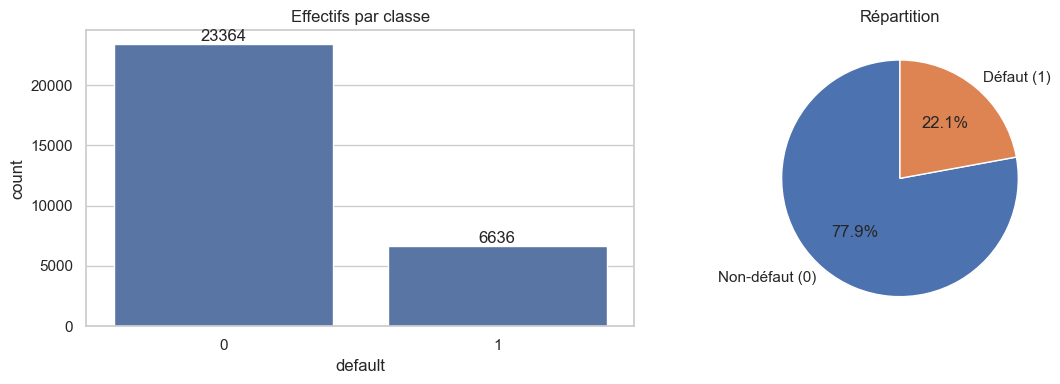

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=TARGET, data=df, ax=axes[0])
axes[0].set_title('Effectifs par classe')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')
axes[1].pie(target_counts, labels=['Non-défaut (0)', 'Défaut (1)'],
            autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'])
axes[1].set_title('Répartition')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_target_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Analyse univariée

### 7.A — Variables numériques continues

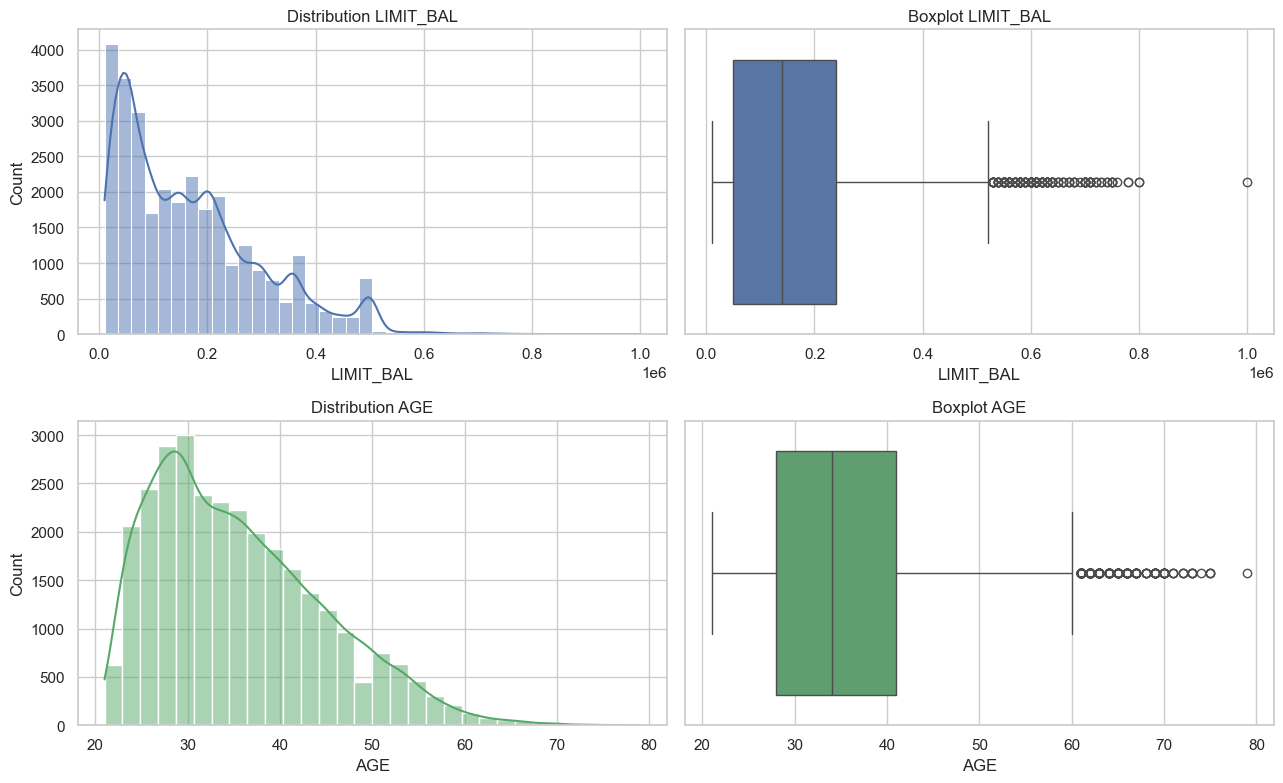

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(df['LIMIT_BAL'], kde=True, ax=axes[0, 0], bins=40, color='#4C72B0')
axes[0, 0].set_title('Distribution LIMIT_BAL')
sns.boxplot(x=df['LIMIT_BAL'], ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Boxplot LIMIT_BAL')
sns.histplot(df['AGE'], kde=True, ax=axes[1, 0], bins=30, color='#55A868')
axes[1, 0].set_title('Distribution AGE')
sns.boxplot(x=df['AGE'], ax=axes[1, 1], color='#55A868')
axes[1, 1].set_title('Boxplot AGE')
plt.tight_layout()
plt.savefig(FIG_DIR / '05a_limit_age.png', dpi=120, bbox_inches='tight')
plt.show()

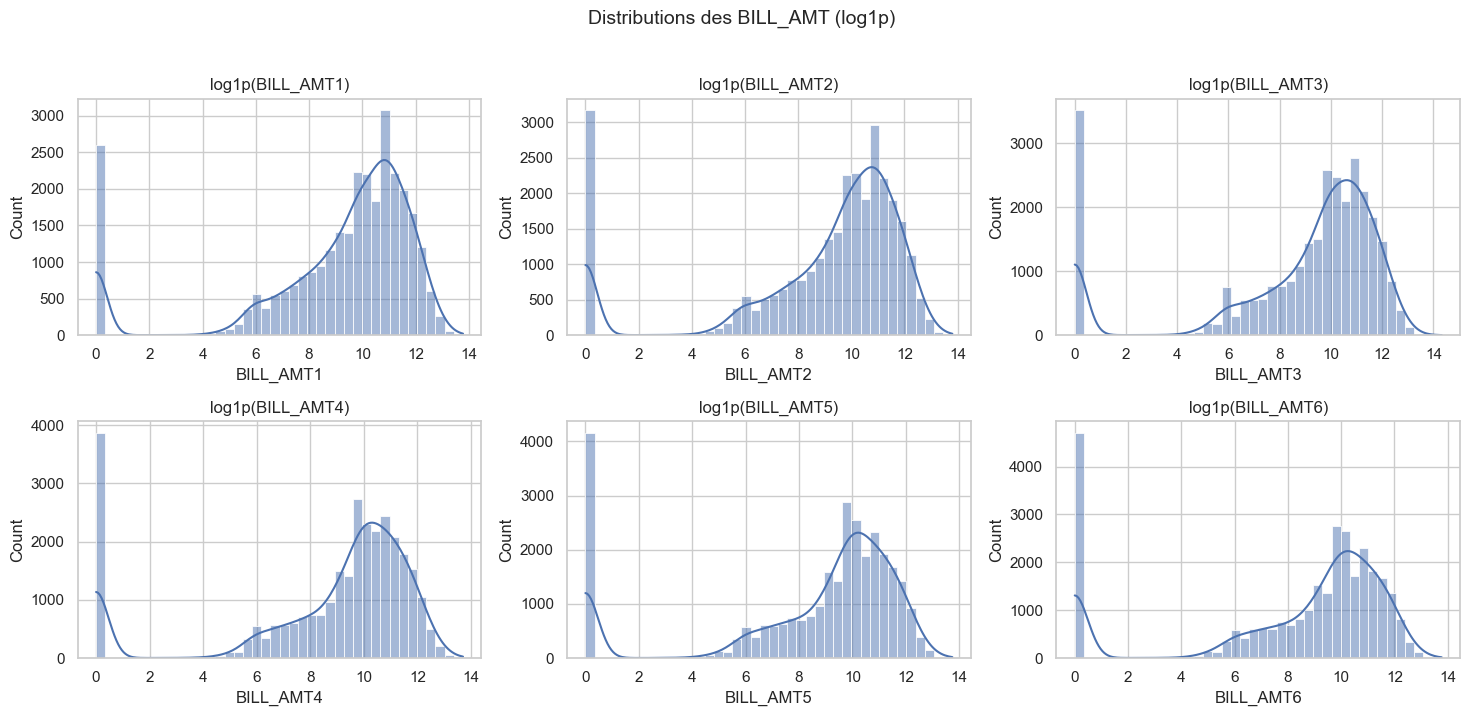

In [26]:
PAY_AMT_COLS = [f'PAY_AMT{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), BILL_COLS):
    sns.histplot(np.log1p(df[col].clip(lower=0)), kde=True, ax=ax, bins=40)
    ax.set_title(f'log1p({col})')
plt.suptitle('Distributions des BILL_AMT (log1p)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '05a_bill_amt_log.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.B — Variables catégorielles

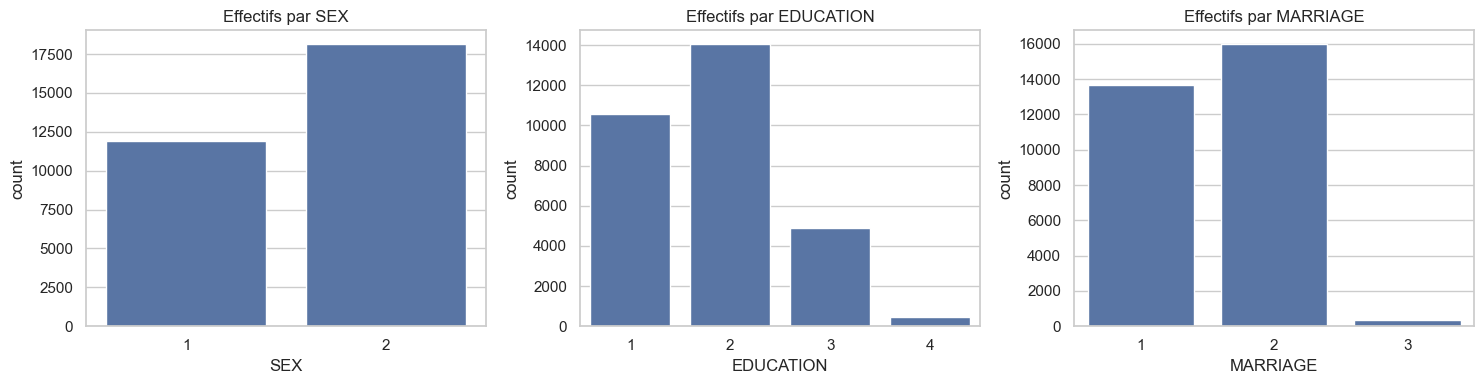

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f'Effectifs par {col}')
plt.tight_layout()
plt.savefig(FIG_DIR / '05b_categoricals.png', dpi=120, bbox_inches='tight')
plt.show()

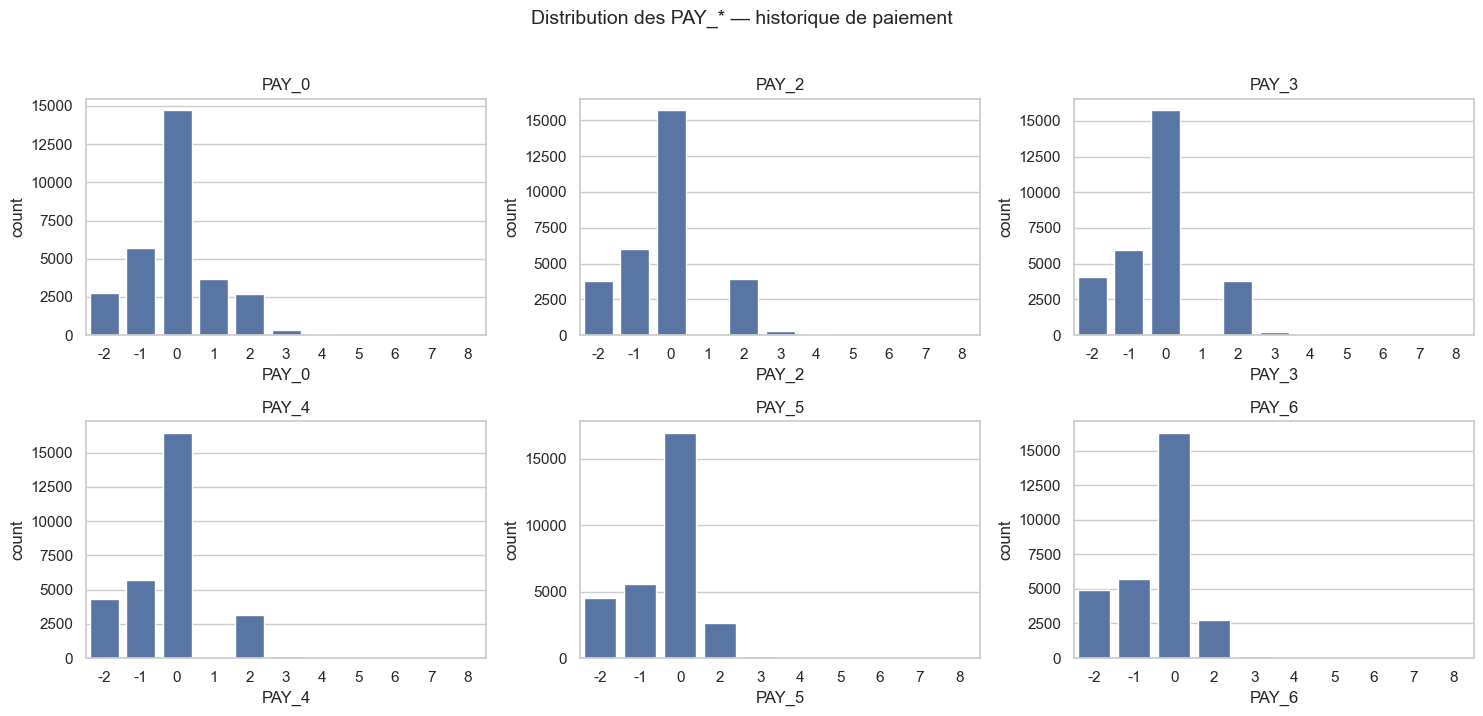

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), PAY_COLS):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f'{col}')
plt.suptitle('Distribution des PAY_* — historique de paiement', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '05b_pay_status.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Analyse bivariée (variable vs cible)

On veut identifier les variables dont la distribution diffère entre
clients défaut et non-défaut.

### 8.A — Boxplots numérique vs cible

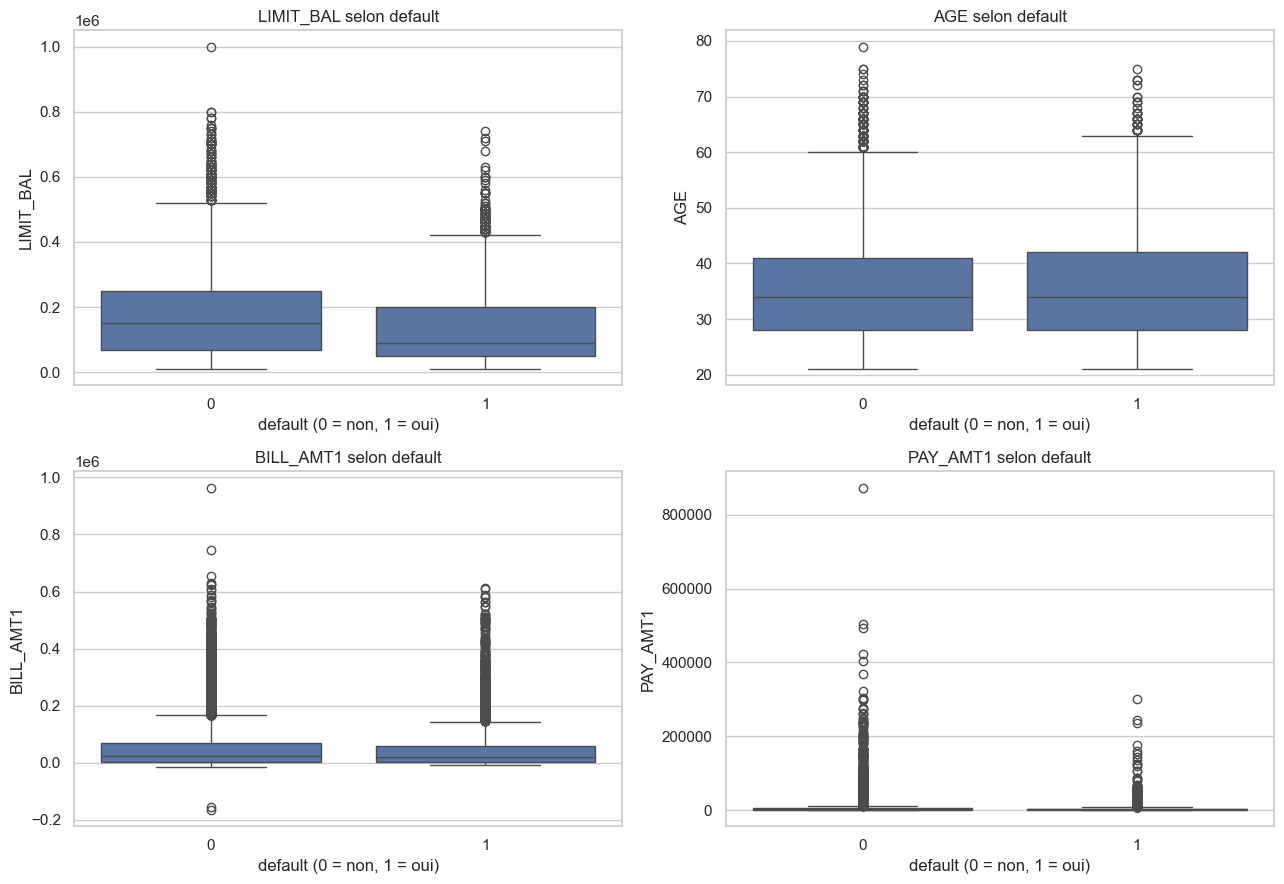

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax)
    ax.set_title(f'{col} selon {TARGET}')
    ax.set_xlabel('default (0 = non, 1 = oui)')
plt.tight_layout()
plt.savefig(FIG_DIR / '06a_boxplots_target.png', dpi=120, bbox_inches='tight')
plt.show()

### 8.B — Test statistique : Mann-Whitney U

Test non-paramétrique : les deux groupes (défaut vs non-défaut) ont-ils
la même distribution sur une variable numérique ?

In [30]:
from scipy.stats import mannwhitneyu
print(f'{"Variable":<15} {"U-stat":>15} {"p-value":>15} {"significatif":>15}')
print('-' * 75)
for col in ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0']:
    g0 = df.loc[df[TARGET] == 0, col]
    g1 = df.loc[df[TARGET] == 1, col]
    u, p = mannwhitneyu(g0, g1, alternative='two-sided')
    sig = 'OUI' if p < 0.001 else 'non'
    print(f'{col:<15} {u:>15.0f} {p:>15.2e} {sig:>15}')

Variable                 U-stat         p-value    significatif
---------------------------------------------------------------------------
LIMIT_BAL              95786286       1.23e-189             OUI
AGE                    76966880        3.73e-01             non
BILL_AMT1              80252446        1.15e-05             OUI
PAY_AMT1               94780733       4.62e-170             OUI
PAY_0                  48108422        0.00e+00             OUI


### 8.C — Taux de défaut par catégorie

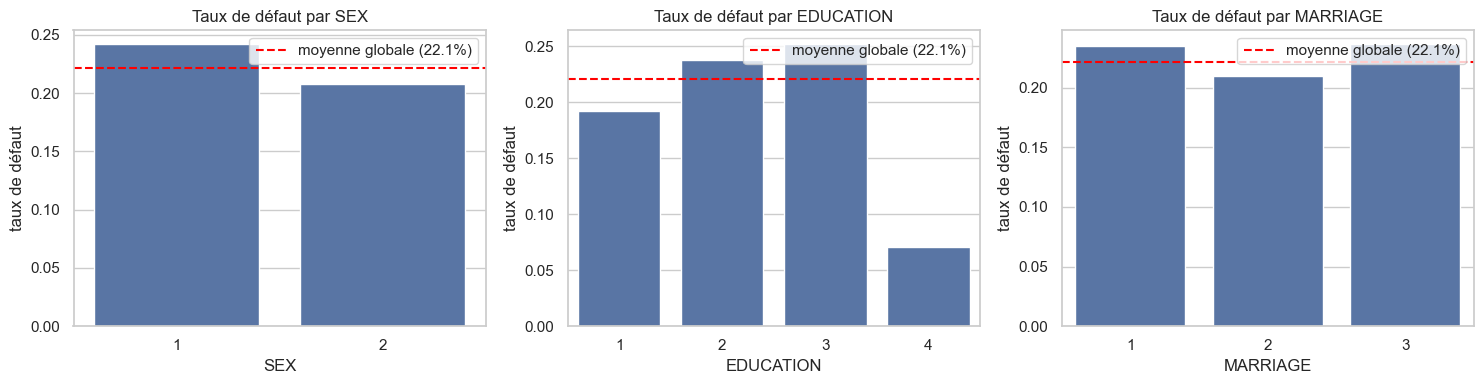

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    rate = df.groupby(col)[TARGET].mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_ylabel('taux de défaut')
    ax.set_title(f'Taux de défaut par {col}')
    ax.axhline(df[TARGET].mean(), color='red', linestyle='--',
               label=f'moyenne globale ({df[TARGET].mean():.1%})')
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06b_default_rate_by_cat.png', dpi=120, bbox_inches='tight')
plt.show()

In [32]:
from scipy.stats import chi2_contingency
print('Test du Chi² (H0: indépendance entre la variable et la cible)')
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    table = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(table)
    sig = 'OUI' if p < 0.001 else 'non'
    print(f'{col:<15} chi2={chi2:>8.2f}  p={p:.2e}  significatif={sig}')

Test du Chi² (H0: indépendance entre la variable et la cible)
SEX             chi2=   47.71  p=4.94e-12  significatif=OUI
EDUCATION       chi2=  160.41  p=1.50e-34  significatif=OUI
MARRIAGE        chi2=   28.13  p=7.79e-07  significatif=OUI


### 8.D — Taux de défaut selon PAY_0 (variable star)

In [33]:
rate_by_pay0 = df.groupby('PAY_0')[TARGET].agg(['mean', 'count']).round(3)
rate_by_pay0.columns = ['taux_defaut', 'effectif']
print(rate_by_pay0)

       taux_defaut  effectif
PAY_0                       
-2           0.132      2759
-1           0.168      5686
 0           0.128     14737
 1           0.339      3688
 2           0.691      2667
 3           0.758       322
 4           0.684        76
 5           0.500        26
 6           0.545        11
 7           0.778         9
 8           0.579        19


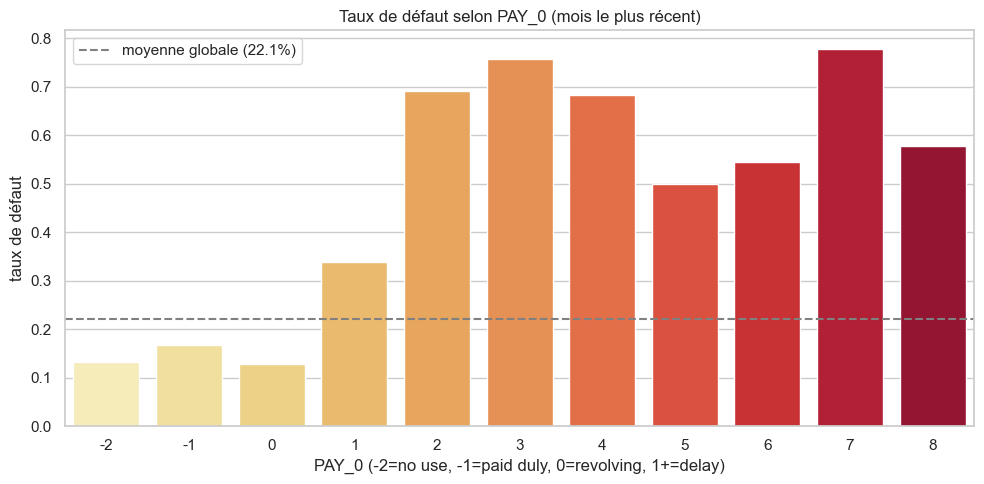

In [34]:
plt.figure(figsize=(10, 5))
rate = df.groupby('PAY_0')[TARGET].mean()
sns.barplot(x=rate.index.astype(str), y=rate.values, palette='YlOrRd')
plt.axhline(df[TARGET].mean(), color='gray', ls='--',
            label=f'moyenne globale ({df[TARGET].mean():.1%})')
plt.title('Taux de défaut selon PAY_0 (mois le plus récent)')
plt.ylabel('taux de défaut')
plt.xlabel('PAY_0 (-2=no use, -1=paid duly, 0=revolving, 1+=delay)')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06b_default_by_pay0.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Analyse multivariée

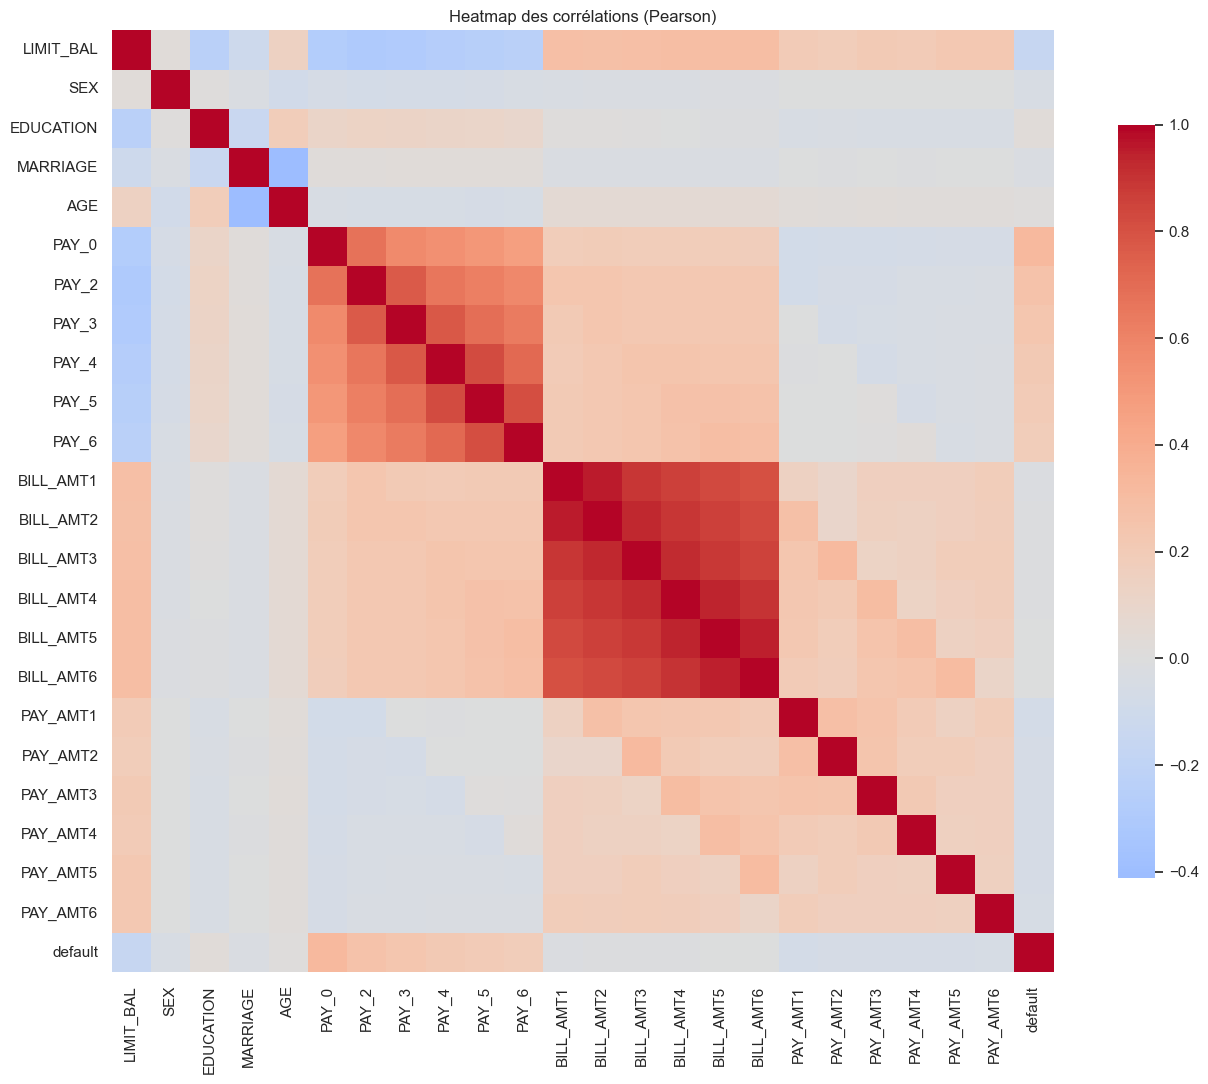

In [35]:
corr = df.corr(method='pearson')
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap des corrélations (Pearson)')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_corr_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [36]:
print('Top 15 variables corrélées avec default (Pearson) :')
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(15).round(3))

Top 15 variables corrélées avec default (Pearson) :
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL    0.154
PAY_AMT1     0.073
PAY_AMT2     0.059
PAY_AMT4     0.057
PAY_AMT3     0.056
PAY_AMT5     0.055
PAY_AMT6     0.053
SEX          0.040
EDUCATION    0.034
Name: default, dtype: float64


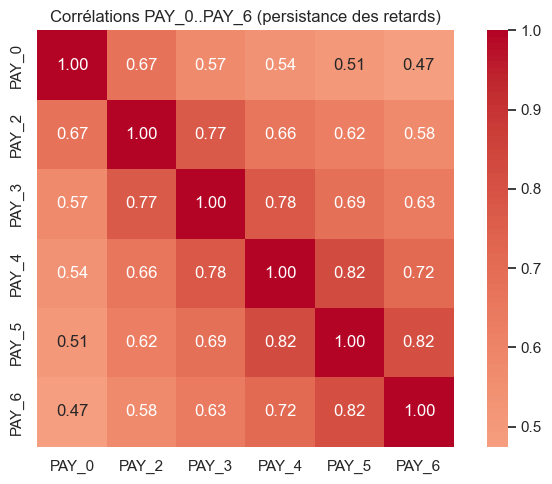

In [37]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[PAY_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Corrélations PAY_0..PAY_6 (persistance des retards)')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_corr_pay_block.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Détection des outliers

On signale les outliers mais on les **garde** : XGBoost et RandomForest y sont
robustes. La LogReg aura un `RobustScaler` dans son pipeline.

In [38]:
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
outliers_pct = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outliers_pct[col] = mask.mean() * 100
pd.Series(outliers_pct).round(2).to_frame('% outliers IQR')

,% outliers IQR
LIMIT_BAL,0.56
AGE,0.91
BILL_AMT1,8.00
PAY_AMT1,9.15


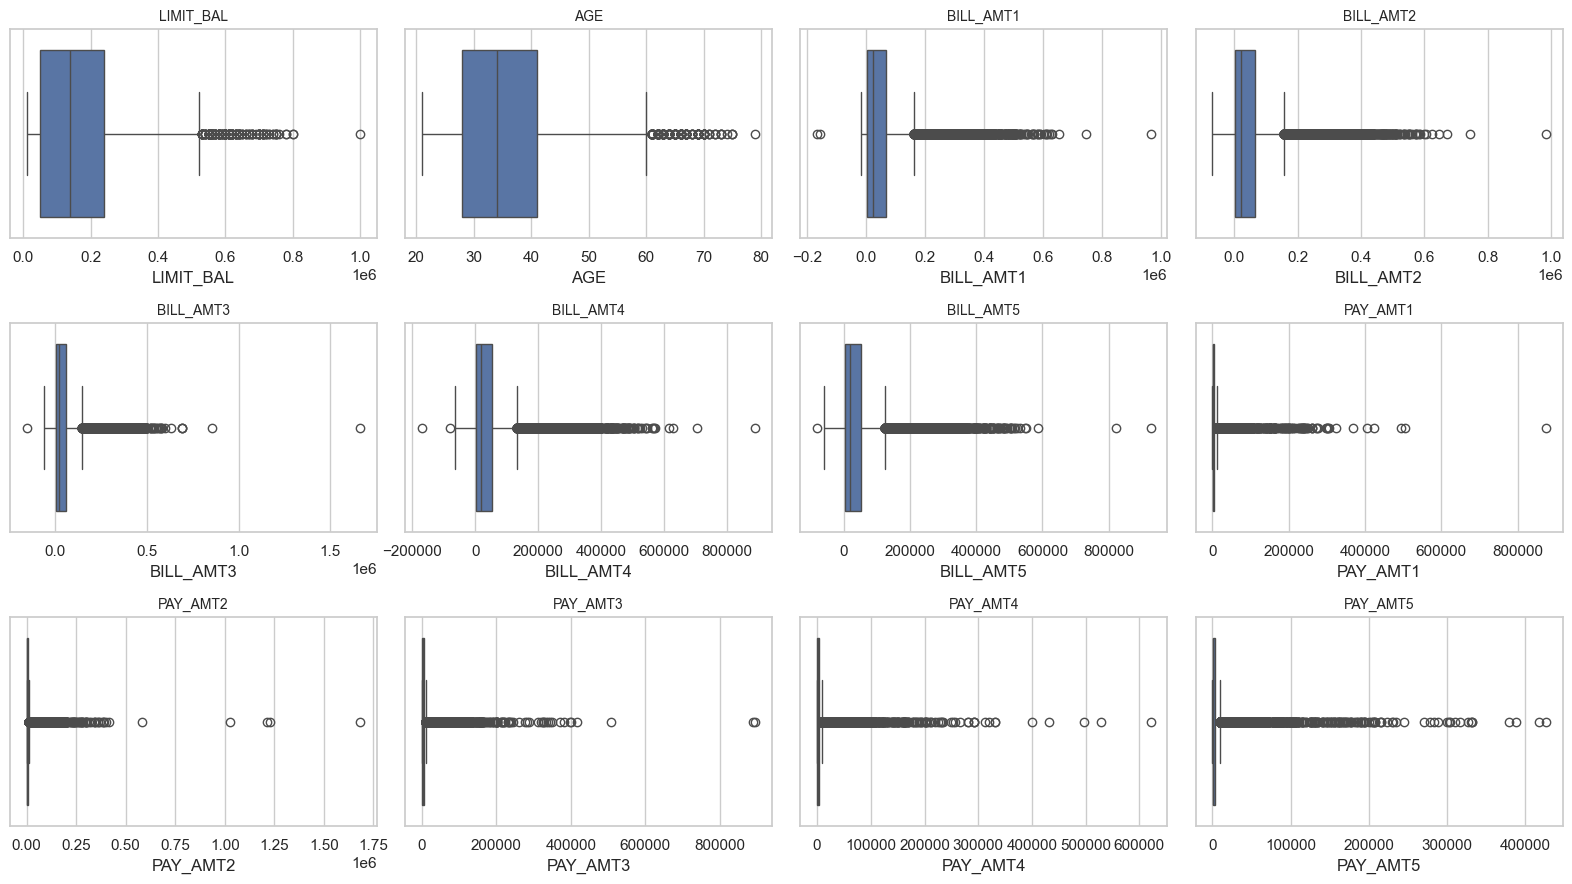

In [39]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
cols_box = ['LIMIT_BAL', 'AGE'] + BILL_COLS[:5] + PAY_AMT_COLS[:5]
for ax, col in zip(axes.ravel(), cols_box):
    sns.boxplot(x=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_boxplots_grid.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Analyses temporelles (6 mois)

Mapping : `PAY_0` = septembre 2005 (le plus récent), `PAY_6` = avril 2005.
Idem pour `BILL_AMT1` (sept.) → `BILL_AMT6` (avril).

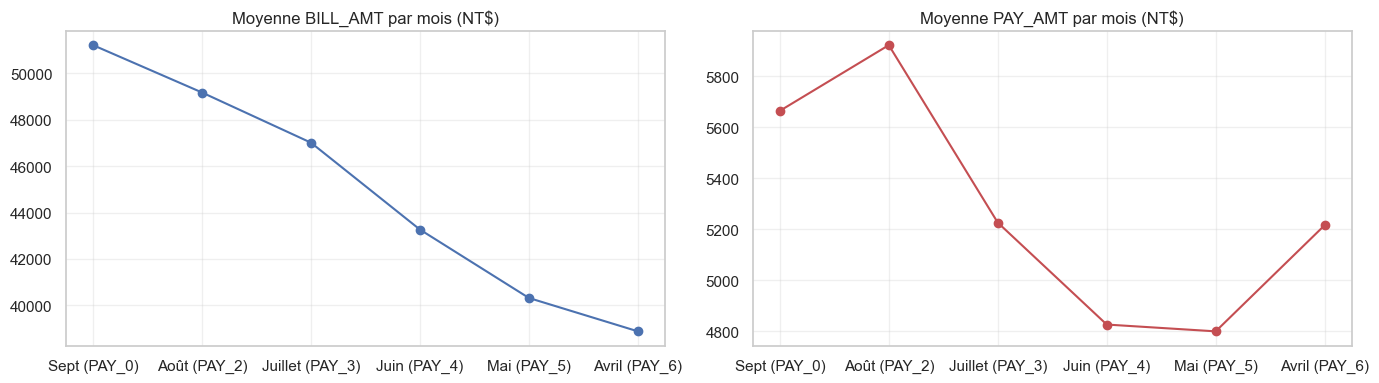

In [40]:
months = ['Sept (PAY_0)', 'Août (PAY_2)', 'Juillet (PAY_3)',
          'Juin (PAY_4)', 'Mai (PAY_5)', 'Avril (PAY_6)']

bill_mean = df[BILL_COLS].mean()
pay_mean = df[PAY_AMT_COLS].mean()
bill_mean.index = months
pay_mean.index = months

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bill_mean.plot(kind='line', marker='o', ax=axes[0], color='#4C72B0')
axes[0].set_title('Moyenne BILL_AMT par mois (NT$)')
axes[0].grid(alpha=0.3)
pay_mean.plot(kind='line', marker='o', ax=axes[1], color='#C44E52')
axes[1].set_title('Moyenne PAY_AMT par mois (NT$)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_temporal_means.png', dpi=120, bbox_inches='tight')
plt.show()

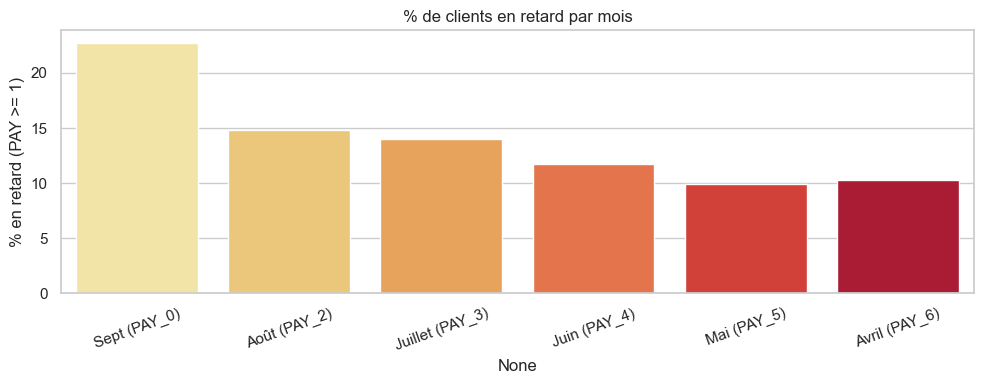

In [41]:
delay_pct = (df[PAY_COLS] >= 1).mean() * 100
delay_pct.index = months
plt.figure(figsize=(10, 4))
sns.barplot(x=delay_pct.index, y=delay_pct.values, palette='YlOrRd')
plt.title('% de clients en retard par mois')
plt.ylabel('% en retard (PAY >= 1)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_delay_pct_per_month.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. 🛠️ Feature engineering détaillé

On construit **12 features dérivées** organisées en **4 thèmes métier** :

| Thème | Features | Intuition business |
|-------|----------|--------------------|
| **A — Comportement de paiement** | `PAY_DELAY_COUNT`, `MAX_DELAY`, `MEAN_PAY_STATUS`, `HAS_EVER_DELAYED` | Résume l'historique de retards sur 6 mois |
| **B — Utilisation du crédit** | `UTIL_RATIO_1`, `MEAN_UTIL`, `MAX_UTIL` | À quel point le client utilise son plafond |
| **C — Capacité de remboursement** | `TOTAL_PAID`, `TOTAL_BILLED`, `PAY_TO_BILL_RATIO` | Le client paye-t-il proportionnellement à ce qu'il doit |
| **D — Tendances temporelles** | `BILL_TREND`, `PAY_TREND` | La dette monte ? Les paiements baissent ? |

Pour chaque feature on présente : **intuition métier → formule → code → validation**.

### 12.A — Thème : comportement de paiement

#### A.1 `PAY_DELAY_COUNT` — Nombre de mois en retard sur 6

- **Intuition** : un client en retard 1 fois sur 6 n'est pas comme un
  client en retard 5 fois sur 6. On compte les mois avec retard.
- **Formule** : `PAY_DELAY_COUNT = Σ 1{PAY_X ≥ 1}` pour les 6 mois
- **Range** : 0 (jamais en retard) à 6 (toujours en retard)

In [42]:
df['PAY_DELAY_COUNT'] = (df[PAY_COLS] >= 1).sum(axis=1).astype(int)

print('Distribution PAY_DELAY_COUNT :')
print(df['PAY_DELAY_COUNT'].value_counts().sort_index())
print()
print('Taux de défaut par PAY_DELAY_COUNT :')
print(df.groupby('PAY_DELAY_COUNT')[TARGET].mean().round(3))

Distribution PAY_DELAY_COUNT :
PAY_DELAY_COUNT
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64

Taux de défaut par PAY_DELAY_COUNT :
PAY_DELAY_COUNT
0    0.117
1    0.298
2    0.388
3    0.509
4    0.573
5    0.574
6    0.703
Name: default, dtype: float64


#### A.2 `MAX_DELAY` — Pire retard observé sur 6 mois

- **Intuition** : un défaut sévère même une seule fois est très révélateur.
- **Formule** : `MAX_DELAY = max(PAY_0, PAY_2, …, PAY_6)`
- **Range** : -2 (pas d'utilisation) à 8 (retard 8+ mois)

In [43]:
df['MAX_DELAY'] = df[PAY_COLS].max(axis=1)
print(df['MAX_DELAY'].value_counts().sort_index())
print()
print('Taux de défaut par MAX_DELAY :')
print(df.groupby('MAX_DELAY')[TARGET].mean().round(3))

MAX_DELAY
-2     2109
-1     3086
 0    14736
 1     1689
 2     7187
 3      789
 4      218
 5       69
 6       25
 7       67
 8       25
Name: count, dtype: int64

Taux de défaut par MAX_DELAY :
MAX_DELAY
-2    0.135
-1    0.147
 0    0.108
 1    0.250
 2    0.436
 3    0.622
 4    0.642
 5    0.507
 6    0.560
 7    0.836
 8    0.560
Name: default, dtype: float64


#### A.3 `MEAN_PAY_STATUS` — Statut de paiement moyen

- **Intuition** : un score continu qui capture le comportement global.
  Plus c'est positif, plus le client est chroniquement en retard.
- **Formule** : `MEAN_PAY_STATUS = mean(PAY_0, PAY_2, …, PAY_6)`

In [44]:
df['MEAN_PAY_STATUS'] = df[PAY_COLS].mean(axis=1)
print(df['MEAN_PAY_STATUS'].describe().round(3))

count    30000.000
mean        -0.182
std          0.982
min         -2.000
25%         -0.833
50%          0.000
75%          0.000
max          6.000
Name: MEAN_PAY_STATUS, dtype: float64


#### A.4 `HAS_EVER_DELAYED` — Flag binaire

- **Intuition** : version simplifiée — a-t-il jamais été en retard ?
- **Formule** : `HAS_EVER_DELAYED = 1 si PAY_DELAY_COUNT > 0 sinon 0`
- **Utilité** : interprétable et simple, peut suffire pour LogReg.

In [45]:
df['HAS_EVER_DELAYED'] = (df['PAY_DELAY_COUNT'] > 0).astype(int)
print('Taux de défaut selon HAS_EVER_DELAYED :')
print(df.groupby('HAS_EVER_DELAYED')[TARGET].mean().round(3))

Taux de défaut selon HAS_EVER_DELAYED :
HAS_EVER_DELAYED
0    0.117
1    0.427
Name: default, dtype: float64


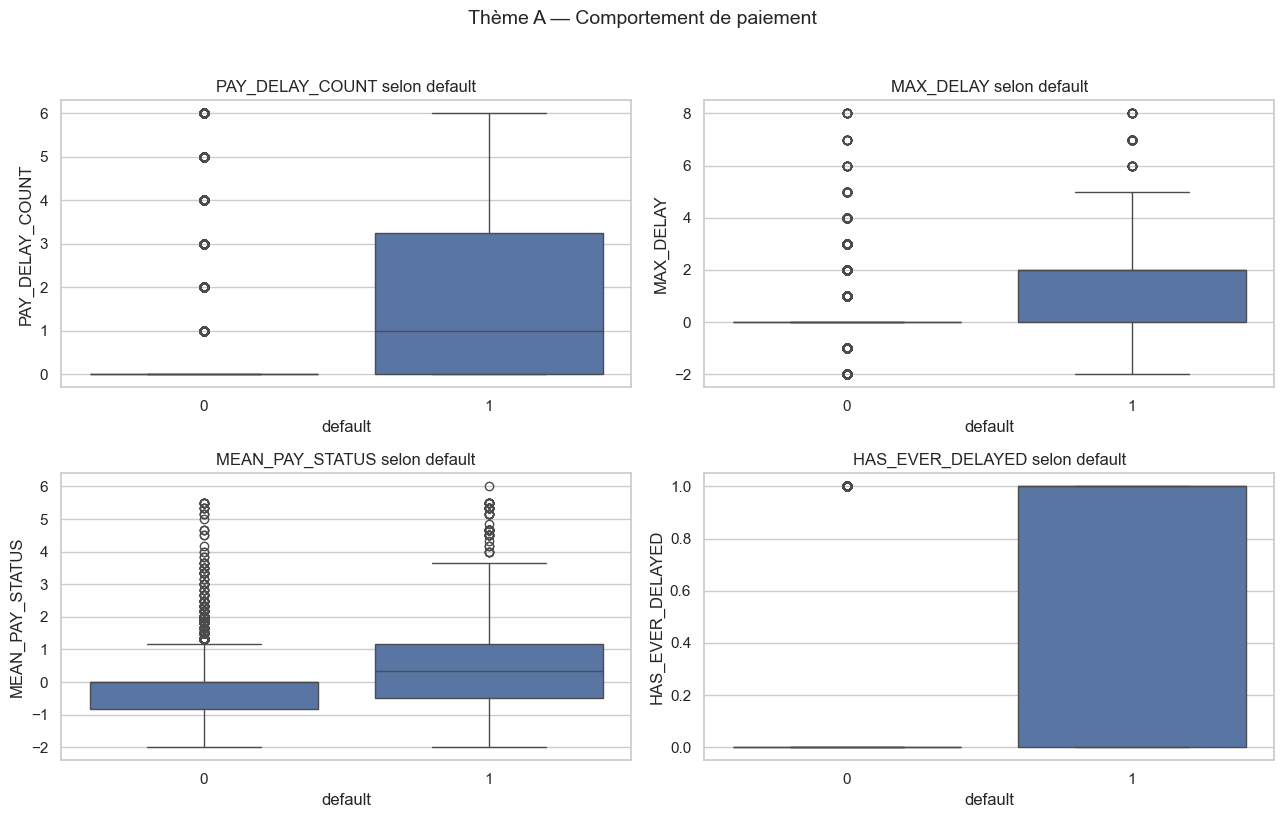

In [46]:
# Validation visuelle Thème A
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(),
                   ['PAY_DELAY_COUNT', 'MAX_DELAY',
                    'MEAN_PAY_STATUS', 'HAS_EVER_DELAYED']):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax)
    ax.set_title(f'{col} selon default')
plt.suptitle('Thème A — Comportement de paiement', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '12a_theme_payment.png', dpi=120, bbox_inches='tight')
plt.show()

### 12.B — Thème : utilisation du crédit

Un client qui utilise 95% de son plafond est plus risqué qu'un client à 20%.
On calcule des **ratios d'utilisation** (utilisation rate = bill / limit).

#### B.1 `UTIL_RATIO_1` — Utilisation au mois le plus récent

- **Intuition** : utilisation actuelle, le signal le plus frais.
- **Formule** : `UTIL_RATIO_1 = BILL_AMT1 / LIMIT_BAL`

In [47]:
# Protection contre division par 0 (LIMIT_BAL ne devrait jamais être 0, mais on protège)
limit_safe = df['LIMIT_BAL'].replace(0, np.nan)
df['UTIL_RATIO_1'] = (df['BILL_AMT1'] / limit_safe).fillna(0)
print(df['UTIL_RATIO_1'].describe().round(3))

count    30000.000
mean         0.424
std          0.411
min         -0.620
25%          0.022
50%          0.314
75%          0.830
max          6.455
Name: UTIL_RATIO_1, dtype: float64


#### B.2 `MEAN_UTIL` — Utilisation moyenne sur 6 mois

- **Intuition** : utilisation chronique (vs ponctuelle).
- **Formule** : `MEAN_UTIL = mean(BILL_AMT_i / LIMIT_BAL)` pour i=1..6

In [48]:
util_block = df[BILL_COLS].div(limit_safe, axis=0)
df['MEAN_UTIL'] = util_block.mean(axis=1).fillna(0)
print(df['MEAN_UTIL'].describe().round(3))

count    30000.000
mean         0.373
std          0.352
min         -0.233
25%          0.030
50%          0.285
75%          0.688
max          5.364
Name: MEAN_UTIL, dtype: float64


#### B.3 `MAX_UTIL` — Pire mois d'utilisation

- **Intuition** : a-t-il déjà flirté avec son plafond ?
- **Formule** : `MAX_UTIL = max(BILL_AMT_i / LIMIT_BAL)` pour i=1..6

In [49]:
df['MAX_UTIL'] = util_block.max(axis=1).fillna(0)
print(df['MAX_UTIL'].describe().round(3))

count    30000.000
mean         0.495
std          0.433
min         -0.100
25%          0.071
50%          0.431
75%          0.923
max         10.689
Name: MAX_UTIL, dtype: float64


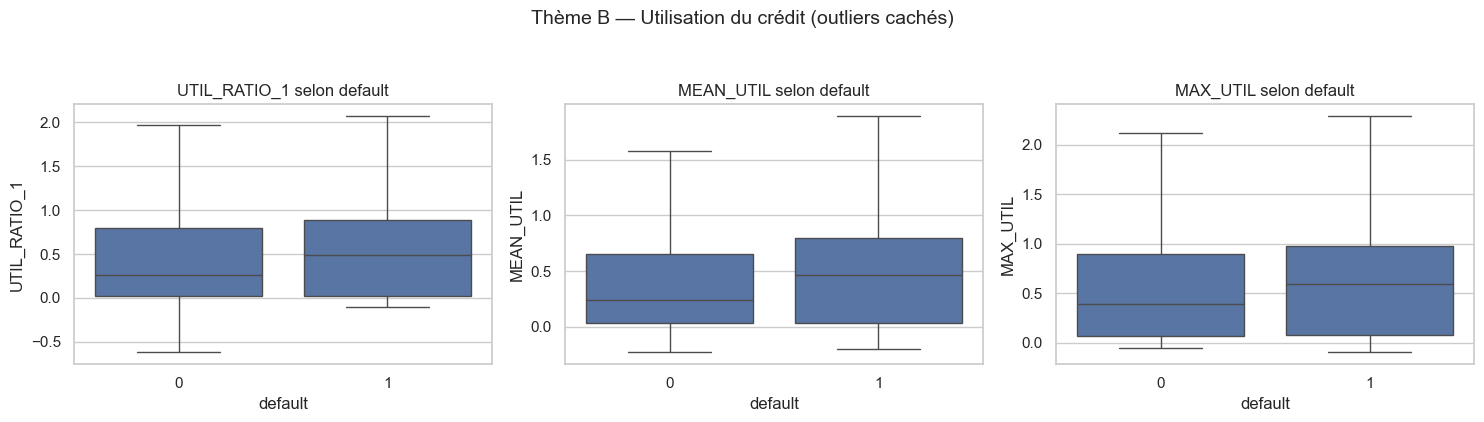

In [50]:
# Validation Thème B
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['UTIL_RATIO_1', 'MEAN_UTIL', 'MAX_UTIL']):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax, showfliers=False)
    ax.set_title(f'{col} selon default')
plt.suptitle('Thème B — Utilisation du crédit (outliers cachés)', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '12b_theme_utilization.png', dpi=120, bbox_inches='tight')
plt.show()

### 12.C — Thème : capacité de remboursement

On combine factures et paiements pour mesurer la capacité du client
à honorer ses engagements globalement sur 6 mois.

#### C.1 `TOTAL_PAID` — Total payé sur 6 mois

- **Formule** : `TOTAL_PAID = Σ PAY_AMT_i` pour i=1..6

In [51]:
df['TOTAL_PAID'] = df[PAY_AMT_COLS].sum(axis=1)
print(df['TOTAL_PAID'].describe().round(0))

count      30000.0
mean       31651.0
std        60828.0
min            0.0
25%         6680.0
50%        14383.0
75%        33504.0
max      3764066.0
Name: TOTAL_PAID, dtype: float64


#### C.2 `TOTAL_BILLED` — Total facturé sur 6 mois

- **Formule** : `TOTAL_BILLED = Σ BILL_AMT_i` pour i=1..6

In [52]:
df['TOTAL_BILLED'] = df[BILL_COLS].sum(axis=1)
print(df['TOTAL_BILLED'].describe().round(0))

count      30000.0
mean      269862.0
std       379564.0
min      -336259.0
25%        28688.0
50%       126311.0
75%       342626.0
max      5263883.0
Name: TOTAL_BILLED, dtype: float64


#### C.3 `PAY_TO_BILL_RATIO` — Capacité de remboursement

- **Intuition** : 1.0 = il paie exactement ce qu'il doit. < 1.0 = il
  accumule de la dette. > 1.0 = il rembourse plus que sa facture
  (rare, souvent dû à un avoir).
- **Formule** : `TOTAL_PAID / TOTAL_BILLED`
- **Protection** : on évite la division par 0 ou par négatif.

In [53]:
billed_safe = df['TOTAL_BILLED'].where(df['TOTAL_BILLED'] > 0, np.nan)
df['PAY_TO_BILL_RATIO'] = (df['TOTAL_PAID'] / billed_safe).fillna(0)
print(df['PAY_TO_BILL_RATIO'].describe().round(3))
print()
print('Médiane par classe :')
print(df.groupby(TARGET)['PAY_TO_BILL_RATIO'].median().round(3))

count    30000.000
mean         0.469
std          5.507
min          0.000
25%          0.041
50%          0.085
75%          0.587
max        797.000
Name: PAY_TO_BILL_RATIO, dtype: float64

Médiane par classe :
default
0    0.107
1    0.055
Name: PAY_TO_BILL_RATIO, dtype: float64


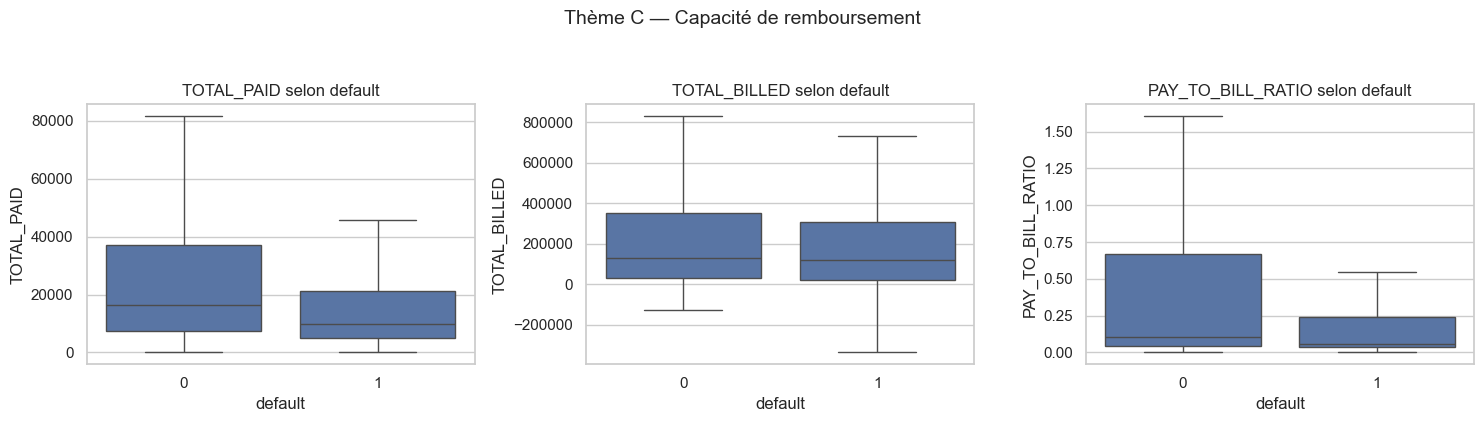

In [54]:
# Validation Thème C (log scale car très skewé)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TOTAL_PAID', 'TOTAL_BILLED', 'PAY_TO_BILL_RATIO']):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax, showfliers=False)
    ax.set_title(f'{col} selon default')
plt.suptitle('Thème C — Capacité de remboursement', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '12c_theme_repayment.png', dpi=120, bbox_inches='tight')
plt.show()

### 12.D — Thème : tendances temporelles

Capturer si la dette monte (BILL_AMT augmente) ou si les paiements
baissent (PAY_AMT diminue) sur les 6 mois.

**Convention** : `BILL_AMT1` = septembre (le plus récent), `BILL_AMT6`
= avril (le plus ancien). Donc `BILL_AMT1 - BILL_AMT6` > 0 signifie
**la dette a augmenté** sur la période.

#### D.1 `BILL_TREND` — Pente de la dette sur 6 mois

- **Intuition** : valeur positive = dette qui monte = mauvais signe.
- **Formule** : `BILL_TREND = (BILL_AMT1 - BILL_AMT6) / 6`

In [55]:
df['BILL_TREND'] = (df['BILL_AMT1'] - df['BILL_AMT6']) / 6
print(df['BILL_TREND'].describe().round(0))
print()
print('Médiane par classe :')
print(df.groupby(TARGET)['BILL_TREND'].median().round(0))

count     30000.0
mean       2059.0
std        7320.0
min      -71465.0
25%        -494.0
50%         154.0
75%        3299.0
max      118054.0
Name: BILL_TREND, dtype: float64

Médiane par classe :
default
0    266.0
1      0.0
Name: BILL_TREND, dtype: float64


#### D.2 `PAY_TREND` — Pente des paiements sur 6 mois

- **Intuition** : valeur positive = paye de plus en plus = bon signe.
- **Formule** : `PAY_TREND = (PAY_AMT1 - PAY_AMT6) / 6`

In [56]:
df['PAY_TREND'] = (df['PAY_AMT1'] - df['PAY_AMT6']) / 6
print(df['PAY_TREND'].describe().round(0))
print()
print('Médiane par classe :')
print(df.groupby(TARGET)['PAY_TREND'].median().round(0))

count     30000.0
mean         75.0
std        3655.0
min      -88111.0
25%         -65.0
50%          83.0
75%         334.0
max      121425.0
Name: PAY_TREND, dtype: float64

Médiane par classe :
default
0    100.0
1     33.0
Name: PAY_TREND, dtype: float64


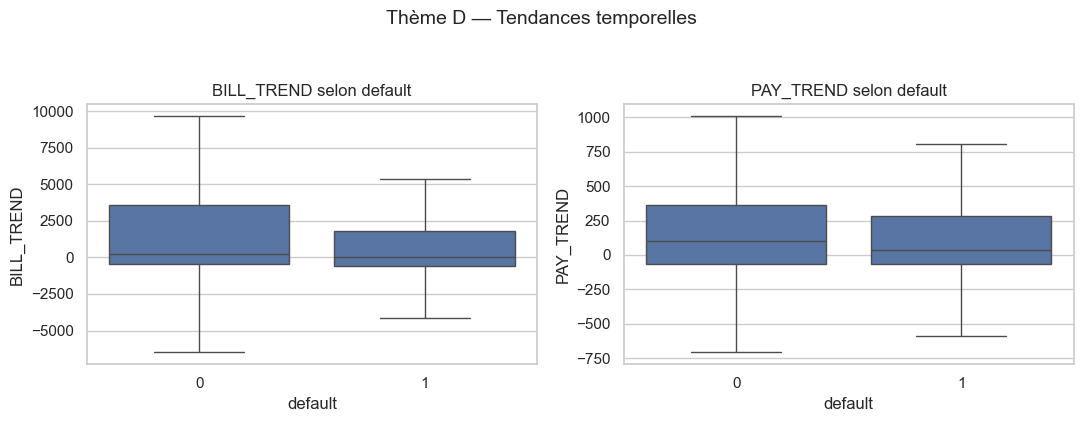

In [57]:
# Validation Thème D
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ['BILL_TREND', 'PAY_TREND']):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax, showfliers=False)
    ax.set_title(f'{col} selon default')
plt.suptitle('Thème D — Tendances temporelles', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '12d_theme_trends.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Validation finale — les nouvelles features sont-elles utiles ?

On compare la corrélation des features dérivées avec la cible vs les
features originales. Si les nouvelles features dominent le classement,
on a bien fait notre travail.

In [58]:
print(f'Dataset enrichi : {df.shape}')
new_cols = ['PAY_DELAY_COUNT', 'MAX_DELAY', 'MEAN_PAY_STATUS', 'HAS_EVER_DELAYED',
            'UTIL_RATIO_1', 'MEAN_UTIL', 'MAX_UTIL',
            'TOTAL_PAID', 'TOTAL_BILLED', 'PAY_TO_BILL_RATIO',
            'BILL_TREND', 'PAY_TREND']
print(f'{len(new_cols)} features ajoutées')

Dataset enrichi : (30000, 36)
12 features ajoutées


In [59]:
# Top 20 corrélations (abs) avec default — features originales + dérivées mélangées
corr_full = df.corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top20 = corr_full.head(20).round(3)

# Marquer les features dérivées
labels = ['🆕 ' + c if c in new_cols else '   ' + c for c in top20.index]
print('Top 20 variables corrélées avec default :')
for label, val in zip(labels, top20.values):
    print(f'  {val:.3f}  {label}')

Top 20 variables corrélées avec default :
  0.398  🆕 PAY_DELAY_COUNT
  0.353  🆕 HAS_EVER_DELAYED
  0.331  🆕 MAX_DELAY
  0.325     PAY_0
  0.282  🆕 MEAN_PAY_STATUS
  0.264     PAY_2
  0.235     PAY_3
  0.217     PAY_4
  0.204     PAY_5
  0.187     PAY_6
  0.154     LIMIT_BAL
  0.115  🆕 MEAN_UTIL
  0.102  🆕 TOTAL_PAID
  0.086  🆕 UTIL_RATIO_1
  0.082  🆕 MAX_UTIL
  0.073     PAY_AMT1
  0.059     PAY_AMT2
  0.057     PAY_AMT4
  0.056     PAY_AMT3
  0.055     PAY_AMT5


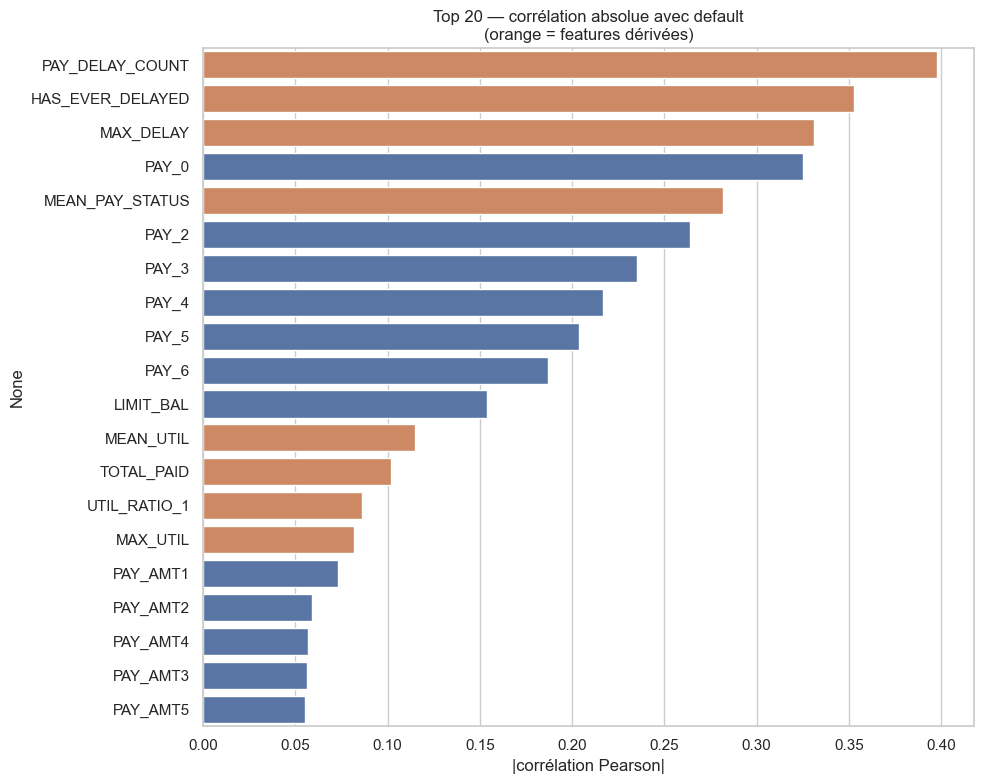

In [60]:
# Visualisation du top 20
plt.figure(figsize=(10, 8))
colors = ['#DD8452' if c in new_cols else '#4C72B0' for c in top20.index]
sns.barplot(x=top20.values, y=top20.index, palette=colors)
plt.title('Top 20 — corrélation absolue avec default\n(orange = features dérivées)')
plt.xlabel('|corrélation Pearson|')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_feature_importance_corr.png', dpi=120, bbox_inches='tight')
plt.show()

In [61]:
# Validation Spearman (robuste aux outliers)
corr_s = df.corr(method='spearman')[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top15_s = corr_s.head(15).round(3)
print('Top 15 corrélations Spearman (abs) avec default :')
for c, v in top15_s.items():
    tag = '🆕' if c in new_cols else '  '
    print(f'  {v:.3f}  {tag} {c}')

Top 15 corrélations Spearman (abs) avec default :
  0.388  🆕 PAY_DELAY_COUNT
  0.353  🆕 HAS_EVER_DELAYED
  0.321  🆕 MAX_DELAY
  0.292     PAY_0
  0.256  🆕 MEAN_PAY_STATUS
  0.217     PAY_2
  0.195     PAY_3
  0.174  🆕 TOTAL_PAID
  0.174     PAY_4
  0.170     LIMIT_BAL
  0.160     PAY_AMT1
  0.159     PAY_5
  0.151     PAY_AMT2
  0.143  🆕 PAY_TO_BILL_RATIO
  0.143     PAY_6


## 14. Sauvegarde du dataset processed

In [62]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(PROCESSED_PATH, index=False)
print(f'Saved → {PROCESSED_PATH.relative_to(ROOT)}')
print(f'Shape : {df.shape}')
print(f'Size  : {PROCESSED_PATH.stat().st_size / 1024:.0f} KB')

Saved → data/processed/credit_clean.parquet
Shape : (30000, 36)
Size  : 3341 KB


## 15. 📌 Synthèse

### Cleaning appliqué
| Opération | Effet |
|-----------|-------|
| Drop `ID` | 25 → 24 colonnes |
| Rename `default.payment.next.month` → `default` | nom Python-friendly |
| EDUCATION : recoder {0, 5, 6} → 4 (others) | 345 lignes |
| MARRIAGE : recoder 0 → 3 (others) | 54 lignes |

### Feature engineering — 12 nouvelles colonnes

| Thème | Features | Description |
|-------|----------|-------------|
| A. Paiement | PAY_DELAY_COUNT, MAX_DELAY, MEAN_PAY_STATUS, HAS_EVER_DELAYED | Historique de retards |
| B. Utilisation | UTIL_RATIO_1, MEAN_UTIL, MAX_UTIL | Bill / Limit |
| C. Remboursement | TOTAL_PAID, TOTAL_BILLED, PAY_TO_BILL_RATIO | Capacité globale |
| D. Tendances | BILL_TREND, PAY_TREND | Évolution 6 mois |

### Dataset final
- **Shape** : 30 000 lignes × 36 colonnes (24 cleaned + 12 engineered)
- **Sauvegarde** : `data/processed/credit_clean.parquet`

### Réutilisation en production

Les mêmes règles sont encapsulées dans `src/scoring/data.py` :

```python
from scoring.data import prepare
df = prepare()   # load_raw → clean → engineer_features
```

Ce module est appelé par le script d'entraînement (`src/scoring/train.py`)
et par l'API FastAPI au moment de la prédiction → **garantie qu'un
client reçoit en prod exactement le même traitement qu'à l'entraînement**.

### Prochaine étape

→ Étape 3 de l'examen : définir la **fonction de score métier**
(coût FN vs coût FP).